In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_excel('/Users/prateek/Desktop/Windows 11 Shared/india-gcc-workforce-analytics/excel/gcc_workforce_analysis.xlsx')

In [8]:
df.head()

,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Sr. HR Recruiter (NON IT),270925008041,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Pow...",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,NaN,NaN,Preferred candidate profile . .,200000.0,400000.0,2.0,4.0
1,Fire And Safety Officer,270925007584,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,5162.0,4.0,"Ensure active Fire Protection System,such as F...",300000.0,500000.0,6.0,11.0
2,Opening For Performance Marketing - Chennai,270925007492,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth ...",12-18 Yrs,Not disclosed,Chennai,1324750,2892.0,4.2,MBA Marketing (preferred Tier II or III B- Sch...,0.0,0.0,12.0,18.0
3,Medical Billing Executive,270925007443,INR,6 Days Ago,GNR Global Services,"Fluent English,Spoken English,Good English Com...",0-3 Yrs,"70,000-2 Lacs PA","Mohali, Chandigarh, Kharar, Zirakpur",123804403,NaN,NaN,Job Title-Medical Billing Executive\nLocation-...,70000.0,200000.0,0.0,3.0
4,Senior Group Product Manager - CNS Therapy,270925007430,INR,6 Days Ago,Cadila Pharmaceuticals,"Product Marketing,CNS,Product Management,Nephr...",5-10 Yrs,8-18 Lacs PA,Ahmedabad,14957,2134.0,3.4,Principal Tasks & Responsibilities : (Please w...,800000.0,1800000.0,5.0,10.0


In [9]:
df.shape

(97929, 17)

In [10]:
df.columns

Index(['title', 'jobId', 'currency', 'jobUploaded', 'companyName',
       'tagsAndSkills', 'experience', 'salary', 'location', 'companyId',
       'ReviewsCount', 'AggregateRating', 'jobDescription', 'minimumSalary',
       'maximumSalary', 'minimumExperience', 'maximumExperience'],
      dtype='str')

In [11]:
df.columns.tolist()

['title',
 'jobId',
 'currency',
 'jobUploaded',
 'companyName',
 'tagsAndSkills',
 'experience',
 'salary',
 'location',
 'companyId',
 'ReviewsCount',
 'AggregateRating',
 'jobDescription',
 'minimumSalary',
 'maximumSalary',
 'minimumExperience',
 'maximumExperience']

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97929 entries, 0 to 97928
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              97929 non-null  str    
 1   jobId              97929 non-null  int64  
 2   currency           97929 non-null  str    
 3   jobUploaded        97929 non-null  str    
 4   companyName        97925 non-null  str    
 5   tagsAndSkills      97358 non-null  str    
 6   experience         95824 non-null  str    
 7   salary             97929 non-null  str    
 8   location           97929 non-null  str    
 9   companyId          97929 non-null  int64  
 10  ReviewsCount       62677 non-null  float64
 11  AggregateRating    62677 non-null  float64
 12  jobDescription     97929 non-null  str    
 13  minimumSalary      97358 non-null  float64
 14  maximumSalary      97358 non-null  float64
 15  minimumExperience  97358 non-null  float64
 16  maximumExperience  97358 non-null

In [13]:
## Missing-value analysis

In [14]:
df.isnull().sum()

title                    0
jobId                    0
currency                 0
jobUploaded              0
companyName              4
tagsAndSkills          571
experience            2105
salary                   0
location                 0
companyId                0
ReviewsCount         35252
AggregateRating      35252
jobDescription           0
minimumSalary          571
maximumSalary          571
minimumExperience      571
maximumExperience      571
dtype: int64

In [15]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_values.sort_values(
    by="missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
ReviewsCount,35252,35.997508
AggregateRating,35252,35.997508
experience,2105,2.149516
maximumExperience,571,0.583075
minimumExperience,571,0.583075
maximumSalary,571,0.583075
tagsAndSkills,571,0.583075
minimumSalary,571,0.583075
companyName,4,0.004085
jobDescription,0,0.000000


In [16]:
## Checking Duplicate Rows

In [17]:
df.duplicated().sum()

np.int64(247)

In [18]:
df["jobId"].duplicated().sum()

np.int64(250)

In [19]:
df.describe()

,jobId,companyId,ReviewsCount,AggregateRating,minimumSalary,maximumSalary,minimumExperience,maximumExperience
count,9.792900e+04,9.792900e+04,62677.000000,62677.000000,9.735800e+04,9.735800e+04,97358.000000,97358.000000
mean,2.069854e+11,2.784642e+07,14662.590264,3.679048,1.983092e+05,3.186096e+05,3.957744,7.732647
std,9.987860e+10,4.979184e+07,24744.514682,0.484096,5.640765e+05,8.417336e+05,3.581196,4.500161
min,1.012500e+10,3.000000e+00,2.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.808250e+11,2.339390e+05,65.000000,3.500000,0.000000e+00,0.000000e+00,1.000000,5.000000
50%,2.508250e+11,2.892790e+06,962.000000,3.700000,0.000000e+00,0.000000e+00,3.000000,7.000000
75%,2.808250e+11,6.398332e+06,12826.000000,3.900000,2.000000e+05,3.750000e+05,5.000000,10.000000
max,3.112240e+11,1.251422e+08,104449.000000,5.000000,7.000000e+07,9.500000e+07,30.000000,35.000000


In [20]:
df.describe(include="object")

/var/folders/r_/dkxgv72x363bpkl_6vsh9s800000gn/T/ipykernel_20608/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,title,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,jobDescription
count,97929,97929,97929,97925,97358,95824,97929,97929,97929
unique,55104,2,30,18668,84307,287,1339,10066,80679
top,Application Developer,INR,4 Days Ago,Accenture,"Retail,Lead generation,Forex,Investment produc...",5-10 Yrs,Not disclosed,Bengaluru,Disclaimer: This job description has been sour...
freq,2039,97800,13973,8204,116,6448,64076,16823,382


In [21]:
df["location"].nunique()

10066

In [22]:
df["location"].value_counts().head(20)

location
Bengaluru                        16823
Hyderabad                         7669
Pune                              6112
Chennai                           4431
Gurugram                          4233
Mumbai                            4157
Noida                             2695
Remote                            1961
Ahmedabad                         1726
Navi Mumbai                       1453
Kolkata                           1049
Hyderabad, Chennai, Bengaluru     1037
Hybrid - Bengaluru                 946
Jaipur                             821
Coimbatore                         618
Hybrid - Hyderabad                 576
Kochi                              528
Vadodara                           528
Hybrid - Pune                      480
Thane                              410
Name: count, dtype: int64

In [23]:
## Creating a copy of raw data for the transformation

In [24]:
df_clean = df.copy()

In [25]:
## Handling duplicate values

In [26]:
df_clean["jobId"].duplicated().sum()

np.int64(250)

In [27]:
duplicate_jobs = df_clean[
    df_clean["jobId"].duplicated(keep=False)
]

duplicate_jobs.sort_values("jobId").head(20)

,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
18159,Senior Manager -Data Modeller,10425004190,INR,9 Days Ago,VOIS,"Teradata SQL,Data Architecture,Data Modeling,D...",10-18 Yrs,35-40 Lacs PA,Hybrid - Pune,647435,1132.0,3.9,"Preferred candidate profile :- Data Modeller,D...",3500000.0,4000000.0,10.0,18.0
18160,Senior Manager -Data Modeller,10425004190,INR,9 Days Ago,VOIS,"Teradata SQL,Data Architecture,Data Modeling,D...",10-18 Yrs,35-40 Lacs PA,Hybrid - Pune,647435,1132.0,3.9,"Preferred candidate profile :- Data Modeller,D...",3500000.0,4000000.0,10.0,18.0
3799,Manual Testing Engineer,11025010305,INR,2 Days Ago,KP Hr And Infra Services,"Database Testing,Web Based Application,Manual ...",1-3 Yrs,5-8 Lacs PA,Pune(Senapati Bapat Road +1),3915296,NaN,NaN,1.Manual testing\n2.Experience in Functional T...,500000.0,800000.0,1.0,3.0
3800,Manual Testing Engineer,11025010305,INR,2 Days Ago,KP Hr And Infra Services,"Database Testing,Web Based Application,Manual ...",1-3 Yrs,5-8 Lacs PA,Pune(Senapati Bapat Road +1),3915296,NaN,NaN,1.Manual testing\n2.Experience in Functional T...,500000.0,800000.0,1.0,3.0
15720,Senior Architect,11025010474,INR,2 Days Ago,One Desing,"Sketchup,Lumion,AutoCAD,REVIT,MS Office,Englis...",0-6 Yrs,1.8-4.2 Lacs PA,Nashik(Govind Nagar),125135755,NaN,NaN,<p>Responsibilities:</p><p>* Manage project ti...,180000.0,420000.0,0.0,6.0
15719,Senior Architect,11025010474,INR,2 Days Ago,One Desing,"Sketchup,Lumion,AutoCAD,REVIT,MS Office,Englis...",0-6 Yrs,1.8-4.2 Lacs PA,Nashik(Govind Nagar),125135755,NaN,NaN,<p>Responsibilities:</p><p>* Manage project ti...,180000.0,420000.0,0.0,6.0
97321,IT Sales Executive Outbound Lead Generation,11025014967,INR,2 Days Ago,Cod Blend Services,"Outbound,Lead Generation,IT Sales,Cold Calling...",0-6 Yrs,2.25-3 Lacs PA,Remote,125133563,NaN,NaN,"Bachelors degree in Business,Marketing,IT,or r...",225000.0,300000.0,0.0,6.0
77589,IT Sales Executive Outbound Lead Generation,11025014967,INR,2 Days Ago,Cod Blend Services,"Outbound,Lead Generation,IT Sales,Cold Calling...",0-6 Yrs,2.25-3 Lacs PA,Remote,125133563,NaN,NaN,"Bachelors degree in Business,Marketing,IT,or r...",225000.0,300000.0,0.0,6.0
77677,Software Engineer,11025018903,INR,2 Days Ago,Lamaxai Technologies,"Technical Consulting,Artificial Intelligence,A...",1-6 Yrs,Not disclosed,"Kochi, Ernakulam",125037527,NaN,NaN,"Experience in AI solutions,AI implementation s...",0.0,0.0,1.0,6.0
15348,Software Engineer,11025018903,INR,2 Days Ago,Lamaxai Technologies,"Technical Consulting,Artificial Intelligence,A...",1-6 Yrs,Not disclosed,"Kochi, Ernakulam",125037527,NaN,NaN,"Experience in AI solutions,AI implementation s...",0.0,0.0,1.0,6.0


In [28]:
df_clean = df_clean.drop_duplicates(
    subset="jobId",
    keep="first"
)

In [29]:
df_clean["jobId"].duplicated().sum()

np.int64(0)

In [30]:
df_clean.shape

(97679, 17)

In [31]:
##  Salary Cleaning

In [32]:
df_clean["minimumSalary"].isnull().sum()

np.int64(571)

In [33]:
(df_clean["minimumSalary"] == 0).sum()

np.int64(63972)

In [34]:
(df_clean["maximumSalary"] == 0).sum()

np.int64(63964)

In [35]:
df_clean["minimumSalary"] = df_clean["minimumSalary"].replace(0, np.nan)
df_clean["maximumSalary"] = df_clean["maximumSalary"].replace(0, np.nan)

In [36]:
## Creating Salary disclosed column

In [37]:
df_clean["salary_disclosed"] = (
    df_clean["minimumSalary"].notna()
    & df_clean["maximumSalary"].notna()
)

In [38]:
df_clean["salary_disclosed"].value_counts()

salary_disclosed
False    64543
True     33136
Name: count, dtype: int64

In [39]:
## Creating estimated salary column

In [40]:
df_clean["estimated_salary"] = (
    df_clean["minimumSalary"]
    + df_clean["maximumSalary"]
) / 2

In [41]:
## Creating Normalize City

In [42]:
def normalize_city(location):
    if pd.isna(location):
        return "Other"

    location = str(location).lower()

    if "hyderabad" in location:
        return "Hyderabad"

    elif "bengaluru" in location or "bangalore" in location:
        return "Bengaluru"

    elif "pune" in location:
        return "Pune"

    elif "chennai" in location:
        return "Chennai"

    elif any(city in location for city in ["gurugram", "gurgaon", "noida", "delhi"]):
        return "Delhi NCR"

    elif "mumbai" in location:
        return "Mumbai"

    else:
        return "Other"

In [43]:
df_clean["normalized_city"] = (
    df_clean["location"].apply(normalize_city)
)

In [44]:
df_clean["normalized_city"].value_counts()

normalized_city
Other        25591
Bengaluru    23005
Hyderabad    13210
Delhi NCR    10821
Pune          9707
Mumbai        8930
Chennai       6415
Name: count, dtype: int64

In [45]:
## Filter target markets

In [46]:
target_cities = [
    "Bengaluru",
    "Hyderabad",
    "Delhi NCR",
    "Pune",
    "Mumbai",
    "Chennai"
]

df_target = df_clean[
    df_clean["normalized_city"].isin(target_cities)
].copy()

In [47]:
df_target.shape

(72088, 20)

In [48]:
salary_by_city = (
    df_target
    .groupby("normalized_city")
    .agg(
        total_jobs=("jobId", "count"),
        salary_records=("estimated_salary", "count"),
        avg_salary=("estimated_salary", "mean"),
        median_salary=("estimated_salary", "median")
    )
    .reset_index()
)

salary_by_city

,normalized_city,total_jobs,salary_records,avg_salary,median_salary
0,Bengaluru,23005,4842,940466.026435,500000.0
1,Chennai,6415,2514,676355.409706,387500.0
2,Delhi NCR,10821,4740,673613.080169,420000.0
3,Hyderabad,13210,3550,996946.478873,550000.0
4,Mumbai,8930,2708,621507.939439,387500.0
5,Pune,9707,2987,752424.840978,450000.0


In [50]:
df_target.nlargest(
    20,
    "estimated_salary"
)[
    [
        "title",
        "companyName",
        "normalized_city",
        "minimumSalary",
        "maximumSalary",
        "estimated_salary",
        "experience"
    ]
]

,title,companyName,normalized_city,minimumSalary,maximumSalary,estimated_salary,experience
4048,Senior Director AI ML,Employers4employees,Bengaluru,20000000.0,30000000.0,25000000.0,15-20 Yrs
4115,Chartered Accountant,European Company,Bengaluru,20000000.0,30000000.0,25000000.0,21-31 Yrs
42231,Openings For Director (Physical design)at Hyde...,Cambio Consulting,Hyderabad,10000000.0,30000000.0,20000000.0,20-29 Yrs
6226,Director Manufacturing Operations,Sampark Career Developers,Chennai,10000000.0,20000000.0,15000000.0,22-30 Yrs
74028,Chief Executive Officer (Nutraceuticals / Bio ...,Holistic Solutions India,Hyderabad,10000000.0,15000000.0,12500000.0,15-24 Yrs
4154,"COO, Rural Startup Co, Hybrid , Consulting + S...",Executive Tracks Associates,Bengaluru,7500000.0,15000000.0,11250000.0,16-24 Yrs
9484,Chief Manufacturing Officer,Career Tree Hr Solutions,Hyderabad,10000000.0,12500000.0,11250000.0,18-28 Yrs
7610,AVP/VP- HR,Tmangoes Hr Consulting,Hyderabad,7000000.0,15000000.0,11000000.0,17-27 Yrs
44891,Marketing Manager SaaS Software,Smartfoodsafe India,Bengaluru,9600000.0,12000000.0,10800000.0,2-6 Yrs
44617,Director ( Head ) Finance - CA/MBA - Shared se...,Indihire Consultants,Hyderabad,9000000.0,12500000.0,10750000.0,15-22 Yrs


In [51]:
## Visualizing Salary Distribution

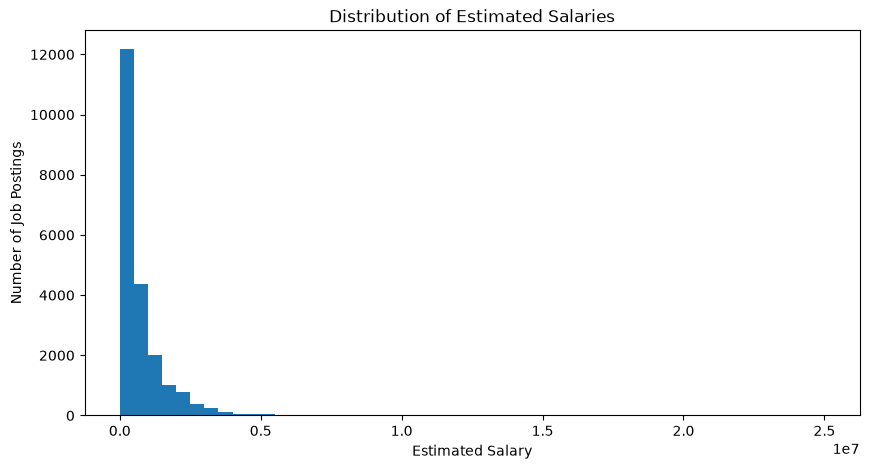

In [52]:
salary_data = df_target[
    df_target["estimated_salary"].notna()
]

plt.figure(figsize=(10, 5))

plt.hist(
    salary_data["estimated_salary"],
    bins=50
)

plt.title("Distribution of Estimated Salaries")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Job Postings")

plt.show()

/var/folders/r_/dkxgv72x363bpkl_6vsh9s800000gn/T/ipykernel_20608/3431680562.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


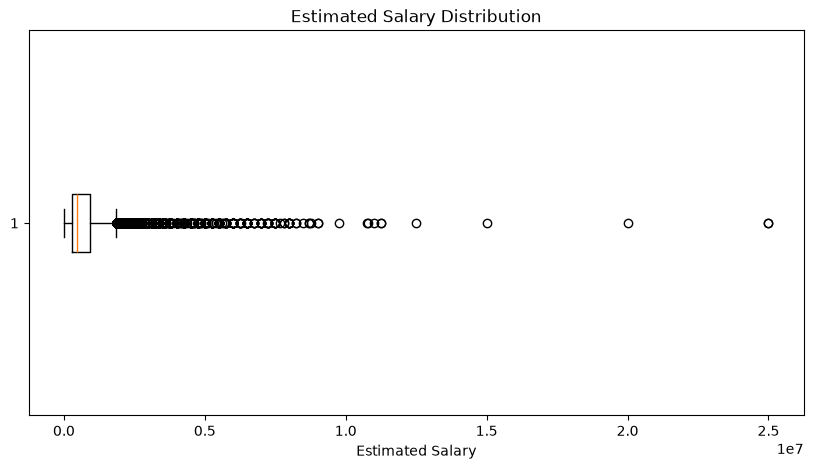

In [53]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    salary_data["estimated_salary"],
    vert=False
)

plt.title("Estimated Salary Distribution")
plt.xlabel("Estimated Salary")

plt.show()

In [54]:
## Inter-quartile range and outliers

In [55]:
q1 = salary_data["estimated_salary"].quantile(0.25)
q3 = salary_data["estimated_salary"].quantile(0.75)

iqr = q3 - q1

q1, q3, iqr

(np.float64(300000.0), np.float64(925000.0), np.float64(625000.0))

In [56]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

lower_bound, upper_bound

(np.float64(-637500.0), np.float64(1862500.0))

In [57]:
salary_outliers = salary_data[
    (salary_data["estimated_salary"] < lower_bound)
    | (salary_data["estimated_salary"] > upper_bound)
]

salary_outliers.shape

(2166, 20)

In [58]:
outlier_percentage = (
    len(salary_outliers)
    / len(salary_data)
) * 100

outlier_percentage

10.149477531512114

In [59]:
salary_outliers[
    [
        "title",
        "normalized_city",
        "experience",
        "minimumSalary",
        "maximumSalary",
        "estimated_salary"
    ]
].sort_values(
    "estimated_salary",
    ascending=False
).head(20)

,title,normalized_city,experience,minimumSalary,maximumSalary,estimated_salary
4115,Chartered Accountant,Bengaluru,21-31 Yrs,20000000.0,30000000.0,25000000.0
4048,Senior Director AI ML,Bengaluru,15-20 Yrs,20000000.0,30000000.0,25000000.0
42231,Openings For Director (Physical design)at Hyde...,Hyderabad,20-29 Yrs,10000000.0,30000000.0,20000000.0
6226,Director Manufacturing Operations,Chennai,22-30 Yrs,10000000.0,20000000.0,15000000.0
74028,Chief Executive Officer (Nutraceuticals / Bio ...,Hyderabad,15-24 Yrs,10000000.0,15000000.0,12500000.0
9484,Chief Manufacturing Officer,Hyderabad,18-28 Yrs,10000000.0,12500000.0,11250000.0
4154,"COO, Rural Startup Co, Hybrid , Consulting + S...",Bengaluru,16-24 Yrs,7500000.0,15000000.0,11250000.0
7610,AVP/VP- HR,Hyderabad,17-27 Yrs,7000000.0,15000000.0,11000000.0
44891,Marketing Manager SaaS Software,Bengaluru,2-6 Yrs,9600000.0,12000000.0,10800000.0
44617,Director ( Head ) Finance - CA/MBA - Shared se...,Hyderabad,15-22 Yrs,9000000.0,12500000.0,10750000.0


In [63]:
salary_city_analysis = (
    salary_data
    .groupby("normalized_city")
    .agg(
        salary_records=("estimated_salary", "count"),
        mean_salary=("estimated_salary", "mean"),
        median_salary=("estimated_salary", "median"),
        min_salary=("estimated_salary", "min"),
        max_salary=("estimated_salary", "max")
    )
    .sort_values("median_salary", ascending=False)
)

salary_city_analysis

,salary_records,mean_salary,median_salary,min_salary,max_salary
normalized_city,,,,,
Hyderabad,3550,996946.478873,550000.0,50000.0,20000000.0
Bengaluru,4842,940466.026435,500000.0,50000.0,25000000.0
Pune,2987,752424.840978,450000.0,9000.0,7800000.0
Delhi NCR,4740,673613.080169,420000.0,50000.0,8000000.0
Chennai,2514,676355.409706,387500.0,1000.0,15000000.0
Mumbai,2708,621507.939439,387500.0,7500.0,8500000.0


In [64]:
salary_outliers["normalized_city"].value_counts()

normalized_city
Bengaluru    679
Hyderabad    561
Delhi NCR    332
Pune         266
Chennai      177
Mumbai       151
Name: count, dtype: int64

In [65]:
outliers_by_city = (
    salary_outliers["normalized_city"]
    .value_counts()
    .rename("outlier_count")
    .to_frame()
)

salary_counts = (
    salary_data["normalized_city"]
    .value_counts()
    .rename("salary_records")
)

outliers_by_city = outliers_by_city.join(salary_counts)

outliers_by_city["outlier_percentage"] = (
    outliers_by_city["outlier_count"]
    / outliers_by_city["salary_records"]
    * 100
)

outliers_by_city

,outlier_count,salary_records,outlier_percentage
normalized_city,,,
Bengaluru,679,4842,14.023131
Hyderabad,561,3550,15.802817
Delhi NCR,332,4740,7.004219
Pune,266,2987,8.905256
Chennai,177,2514,7.040573
Mumbai,151,2708,5.576071


In [66]:
## Experience Analysis

In [67]:
df_target[
    [
        "experience",
        "minimumExperience",
        "maximumExperience"
    ]
].head(20)

,experience,minimumExperience,maximumExperience
2,12-18 Yrs,12.0,18.0
5,10-15 Yrs,10.0,15.0
6,3-5 Yrs,3.0,5.0
9,4-14 Yrs,4.0,14.0
15,1-6 Yrs,1.0,6.0
21,0-5 Yrs,0.0,5.0
23,NaN,1.0,5.0
25,0-5 Yrs,0.0,5.0
33,5-10 Yrs,5.0,10.0
34,8-13 Yrs,8.0,13.0


In [68]:
df_target[
    [
        "minimumExperience",
        "maximumExperience"
    ]
].describe()

,minimumExperience,maximumExperience
count,71666.000000,71666.000000
mean,4.234616,8.047791
std,3.616337,4.513993
min,0.000000,0.000000
25%,2.000000,5.000000
50%,3.000000,8.000000
75%,6.000000,10.000000
max,30.000000,35.000000


In [69]:
df_target["minimumExperience"].value_counts().sort_index()

minimumExperience
0.0      7887
1.0      9632
2.0      8814
3.0     10703
4.0      5919
5.0      9893
6.0      4192
7.0      3236
8.0      3679
9.0       771
10.0     2714
11.0      207
12.0     1158
13.0      248
14.0      177
15.0     2095
16.0       76
17.0       22
18.0      106
19.0       15
20.0       96
21.0        7
22.0        3
24.0        1
25.0        6
27.0        1
28.0        2
30.0        6
Name: count, dtype: int64

In [70]:
## Creating Estimated Experience

In [71]:
df_clean["estimated_experience"] = (
    df_clean["minimumExperience"]
    + df_clean["maximumExperience"]
) / 2

In [72]:
df_clean[
    ["minimumExperience", "maximumExperience"]
].isnull().sum()

minimumExperience    571
maximumExperience    571
dtype: int64

In [73]:
def classify_experience(years):
    if pd.isna(years):
        return "Unknown"
    elif years <= 2:
        return "Entry Level"
    elif years <= 5:
        return "Mid Level"
    elif years <= 10:
        return "Senior Level"
    else:
        return "Leadership / Expert"

In [74]:
df_clean["experience_level"] = (
    df_clean["estimated_experience"]
    .apply(classify_experience)
)

In [75]:
df_clean["experience_level"].value_counts()

experience_level
Senior Level           35849
Mid Level              34840
Entry Level            14615
Leadership / Expert    11804
Unknown                  571
Name: count, dtype: int64

In [77]:
## Experience by city

In [78]:
df_target = df_clean[
    df_clean["normalized_city"].isin(target_cities)
].copy()

In [79]:
experience_by_city = pd.crosstab(
    df_target["normalized_city"],
    df_target["experience_level"],
    normalize="index"
) * 100

experience_by_city.round(2)

experience_level,Entry Level,Leadership / Expert,Mid Level,Senior Level,Unknown
normalized_city,,,,,
Bengaluru,9.03,15.26,30.47,44.63,0.61
Chennai,19.10,11.08,34.64,34.54,0.64
Delhi NCR,18.19,9.80,41.33,29.55,1.14
Hyderabad,9.34,14.28,27.62,48.57,0.19
Mumbai,19.24,10.80,39.51,29.89,0.57
Pune,11.25,14.65,32.05,41.62,0.43


In [80]:
salary_by_experience = (
    df_target[
        df_target["salary_disclosed"]
    ]
    .groupby("experience_level")
    .agg(
        salary_records=("estimated_salary", "count"),
        mean_salary=("estimated_salary", "mean"),
        median_salary=("estimated_salary", "median")
    )
    .sort_values("median_salary")
)

salary_by_experience

,salary_records,mean_salary,median_salary
experience_level,,,
Entry Level,4670,3.073459e+05,275000.0
Mid Level,8985,4.904105e+05,400000.0
Senior Level,5756,1.195391e+06,1000000.0
Leadership / Expert,1930,2.173265e+06,1750000.0


In [81]:
city_experience_salary = (
    df_target[
        df_target["salary_disclosed"]
    ]
    .groupby(
        ["normalized_city", "experience_level"]
    )
    .agg(
        salary_records=("estimated_salary", "count"),
        median_salary=("estimated_salary", "median")
    )
    .reset_index()
)

city_experience_salary

,normalized_city,experience_level,salary_records,median_salary
0,Bengaluru,Entry Level,922,300000.0
1,Bengaluru,Leadership / Expert,441,2125000.0
2,Bengaluru,Mid Level,2049,412500.0
3,Bengaluru,Senior Level,1430,1200000.0
4,Chennai,Entry Level,723,262500.0
5,Chennai,Leadership / Expert,219,1550000.0
6,Chennai,Mid Level,961,375000.0
7,Chennai,Senior Level,611,850000.0
8,Delhi NCR,Entry Level,1162,287500.0
9,Delhi NCR,Leadership / Expert,309,1800000.0


In [82]:
## Workforce classification

In [83]:
df_target["title"].value_counts().head(50)

title
Application Developer                    1956
Application Lead                         1289
Software Development Engineer             475
Trust & Safety New Associate              348
Sales Executive                           305
Business Development Executive            261
Java Developer                            238
Business Development Manager              210
Data Engineer                             207
Sales Manager                             196
Senior Software Engineer                  193
Application Support Engineer              191
Software Development Lead                 178
Java Full Stack Developer                 164
Technical Lead - L1                       164
Software Engineer                         159
Customer Support Executive                148
AI / ML Engineer                          148
Business Analyst                          143
Developer - L3                            142
Graphic Designer                          124
Relationship Manager        

In [104]:
def classify_workforce(title):

    if pd.isna(title):
        return "Other"

    title = str(title).lower().strip()

    # AI / ML
    if any(keyword in title for keyword in [
        "machine learning",
        "ml engineer",
        "artificial intelligence",
        "ai engineer",
        "data scientist",
        "deep learning",
        "nlp engineer",
        "computer vision engineer",
        "generative ai",
        "genai engineer",
        "mlops"
    ]):
        return "AI / ML"

    # Data Engineering
    elif any(keyword in title for keyword in [
        "data engineer",
        "etl developer",
        "etl engineer",
        "big data engineer",
        "analytics engineer",
        "data architect"
    ]):
        return "Data Engineering"

    # Data Analytics
    elif any(keyword in title for keyword in [
        "data analyst",
        "business analyst",
        "bi analyst",
        "business intelligence analyst",
        "power bi developer",
        "power bi analyst",
        "reporting analyst",
        "analytics analyst"
    ]):
        return "Data Analytics"

    # Cybersecurity
    elif any(keyword in title for keyword in [
        "cybersecurity",
        "cyber security",
        "security analyst",
        "security engineer",
        "security architect",
        "soc analyst",
        "information security",
        "application security",
        "cloud security"
    ]):
        return "Cybersecurity"

    # Cloud / DevOps
    elif any(keyword in title for keyword in [
        "devops",
        "cloud engineer",
        "cloud architect",
        "site reliability",
        "sre engineer",
        "platform engineer",
        "infrastructure engineer"
    ]):
        return "Cloud / DevOps"

    # Software Engineering
    elif any(keyword in title for keyword in [
        "software engineer",
        "software developer",
        "software development engineer",
        "software development lead",
        "application developer",
        "python developer",
        "java developer",
        "dot net developer",
        ".net developer",
        "backend developer",
        "backend engineer",
        "front end developer",
        "frontend developer",
        "frontend engineer",
        "full stack",
        "fullstack",
        "web developer",
        "mobile developer",
        "android developer",
        "ios developer",
        "salesforce developer"
    ]):
        return "Software Engineering"

    else:
        return "Other"

In [105]:
df_clean["workforce_category"] = (
    df_clean["title"].apply(classify_workforce)
)

In [106]:
df_target = df_clean[
    df_clean["normalized_city"].isin(target_cities)
].copy()

In [107]:
df_target["workforce_category"].value_counts()

workforce_category
Other                   60770
Software Engineering     7384
Cloud / DevOps            960
Data Engineering          898
AI / ML                   826
Data Analytics            753
Cybersecurity             497
Name: count, dtype: int64

In [108]:
(
    df_target["workforce_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

workforce_category
Other                   84.30
Software Engineering    10.24
Cloud / DevOps           1.33
Data Engineering         1.25
AI / ML                  1.15
Data Analytics           1.04
Cybersecurity            0.69
Name: proportion, dtype: float64

In [109]:
for category in df_target["workforce_category"].unique():

    print("\n", category)

    print(
        df_target[
            df_target["workforce_category"] == category
        ]["title"].value_counts().head(10)
    )


 Other
title
Application Lead                  1289
Trust & Safety New Associate       348
Sales Executive                    305
Business Development Executive     261
Business Development Manager       210
Sales Manager                      196
Application Support Engineer       191
Technical Lead - L1                164
Customer Support Executive         148
Developer - L3                     142
Name: count, dtype: int64

 Cloud / DevOps
title
Devops Engineer                 71
DevOps Engineer                 44
Site Reliability Engineer       37
Data Platform Engineer          31
Azure Devops Engineer           25
Senior DevOps Engineer          24
Senior Devops Engineer          22
Cloud Engineer                  20
Cloud Platform Engineer         13
Technology Platform Engineer    11
Name: count, dtype: int64

 Software Engineering
title
Application Developer            1956
Software Development Engineer     475
Java Developer                    238
Senior Software Engineer    

In [110]:
## Workforce Demand by City

In [111]:
workforce_by_city = pd.crosstab(
    df_target["normalized_city"],
    df_target["workforce_category"]
)

workforce_by_city

workforce_category,AI / ML,Cloud / DevOps,Cybersecurity,Data Analytics,Data Engineering,Other,Software Engineering
normalized_city,,,,,,,
Bengaluru,338,375,214,252,330,18355,3141
Chennai,68,62,29,70,64,5602,520
Delhi NCR,80,103,55,89,80,9853,561
Hyderabad,163,218,89,166,249,10756,1569
Mumbai,37,49,44,74,28,8242,456
Pune,140,153,66,102,147,7962,1137


In [112]:
workforce_share_by_city = pd.crosstab(
    df_target["normalized_city"],
    df_target["workforce_category"],
    normalize="index"
) * 100

workforce_share_by_city.round(2)

workforce_category,AI / ML,Cloud / DevOps,Cybersecurity,Data Analytics,Data Engineering,Other,Software Engineering
normalized_city,,,,,,,
Bengaluru,1.47,1.63,0.93,1.10,1.43,79.79,13.65
Chennai,1.06,0.97,0.45,1.09,1.00,87.33,8.11
Delhi NCR,0.74,0.95,0.51,0.82,0.74,91.05,5.18
Hyderabad,1.23,1.65,0.67,1.26,1.88,81.42,11.88
Mumbai,0.41,0.55,0.49,0.83,0.31,92.30,5.11
Pune,1.44,1.58,0.68,1.05,1.51,82.02,11.71


In [113]:
tech_jobs = df_target[
    df_target["workforce_category"] != "Other"
].copy()

In [114]:
tech_workforce_mix = pd.crosstab(
    tech_jobs["normalized_city"],
    tech_jobs["workforce_category"],
    normalize="index"
) * 100

tech_workforce_mix.round(2)

workforce_category,AI / ML,Cloud / DevOps,Cybersecurity,Data Analytics,Data Engineering,Software Engineering
normalized_city,,,,,,
Bengaluru,7.27,8.06,4.60,5.42,7.10,67.55
Chennai,8.36,7.63,3.57,8.61,7.87,63.96
Delhi NCR,8.26,10.64,5.68,9.19,8.26,57.95
Hyderabad,6.64,8.88,3.63,6.76,10.15,63.94
Mumbai,5.38,7.12,6.40,10.76,4.07,66.28
Pune,8.02,8.77,3.78,5.85,8.42,65.16


In [115]:
## Workforce Salary

In [116]:
workforce_salary = (
    tech_jobs[
        tech_jobs["salary_disclosed"]
    ]
    .groupby("workforce_category")
    .agg(
        jobs=("jobId", "count"),
        mean_salary=("estimated_salary", "mean"),
        median_salary=("estimated_salary", "median")
    )
    .sort_values("median_salary", ascending=False)
)

workforce_salary

,jobs,mean_salary,median_salary
workforce_category,,,
AI / ML,100,2.072350e+06,2137500.0
Data Engineering,161,1.866149e+06,1800000.0
Cloud / DevOps,136,1.811581e+06,1775000.0
Software Engineering,774,1.532732e+06,1450000.0
Data Analytics,140,1.248507e+06,1150000.0
Cybersecurity,64,1.478711e+06,1075000.0


In [117]:
other_titles = (
    df_target[
        df_target["workforce_category"] == "Other"
    ]["title"]
    .value_counts()
)

other_titles.head(50)

title
Application Lead                          1289
Trust & Safety New Associate               348
Sales Executive                            305
Business Development Executive             261
Business Development Manager               210
Sales Manager                              196
Application Support Engineer               191
Technical Lead - L1                        164
Customer Support Executive                 148
Developer - L3                             142
Graphic Designer                           124
Relationship Manager                       113
Application Tech Support Practitioner      112
Application Designer                       109
Account Executive                          107
Area Sales Manager                          93
Business Architect                          90
Customer Service Executive                  89
Customer Care Executive                     88
Project Manager                             87
Accountant                                  81
Lead Ad

In [118]:
tech_terms = [
    "developer",
    "engineer",
    "analyst",
    "architect",
    "data",
    "cloud",
    "security",
    "python",
    "java",
    "software",
    "technology"
]

for term in tech_terms:
    print(f"\n--- {term.upper()} ---")

    print(
        df_target[
            (df_target["workforce_category"] == "Other")
            &
            (df_target["title"].str.contains(
                term,
                case=False,
                na=False
            ))
        ]["title"]
        .value_counts()
        .head(10)
    )


--- DEVELOPER ---
title
Developer - L3             142
Developer - L4              65
Servicenow Developer        41
Java Back End Developer     41
Snowflake Developer         38
React JS Developer          32
Mainframe Developer         25
React Native Developer      24
Angular Developer           23
ServiceNow Developer        22
Name: count, dtype: int64

--- ENGINEER ---
title
Application Support Engineer            191
Quality Engineer (Tester)                67
Network Engineer                         49
Test Engineer - L3                       44
Design Engineer                          38
Sales Engineer                           36
Engineering Manager                      34
Quality Engineer                         32
Quality Engineering Lead (Test Lead)     31
Site Engineer                            28
Name: count, dtype: int64

--- ANALYST ---
title
Analyst                                     51
Financial Analyst                           39
Quality Analyst                 

In [119]:
validation_sample = (
    tech_jobs[
        ["title", "workforce_category"]
    ]
    .sample(
        n=100,
        random_state=42
    )
)

validation_sample

,title,workforce_category
26196,Application Developer-Process Management (BPM),Software Engineering
30276,Application Developer,Software Engineering
95511,Java Developer,Software Engineering
19334,Enterprise Solution Architect Java and Full Stack,Software Engineering
74159,"Lead I - Software Engineering - .Net,React,C# ...",Software Engineering
...,...,...
25415,Software Development Engineer,Software Engineering
40942,Senior Platform Engineer,Cloud / DevOps
50069,GCP Data Engineer - Jr GCP Data Engineer - Sr ...,Data Engineering
248,"Staff Software Engineer( C# , .Net)",Software Engineering


In [120]:
classification_coverage = (
    len(tech_jobs)
    / len(df_target)
    * 100
)

classification_coverage

15.700255243591165

In [121]:
other_titles.head(50)

title
Application Lead                          1289
Trust & Safety New Associate               348
Sales Executive                            305
Business Development Executive             261
Business Development Manager               210
Sales Manager                              196
Application Support Engineer               191
Technical Lead - L1                        164
Customer Support Executive                 148
Developer - L3                             142
Graphic Designer                           124
Relationship Manager                       113
Application Tech Support Practitioner      112
Application Designer                       109
Account Executive                          107
Area Sales Manager                          93
Business Architect                          90
Customer Service Executive                  89
Customer Care Executive                     88
Project Manager                             87
Accountant                                  81
Lead Ad